Read header and print it

In [1]:
from tttrkit.ptuio.reader import TTTRReader
from tttrkit.ptuio.utils import estimate_tcspc_bins
import numpy as np

reader = TTTRReader(r"C:\Users\dalibor\Data\2025-10-23_NADH_test\2025-10-23_NADH_test.sptw\U2OS_NADH6.ptu")
for key, value in reader.header.tags.items():
    if 'Comment' in key:
        print(f'{key}: {value}')


wrap = reader.header.tags.get("TTResultFormat_WrapAround", 1024)
repetition_rate = reader.header.tags.get("TTResult_SyncRate",40e6)  
tcspc_resolution = reader.header.tags.get("MeasDesc_Resolution",5e-12)
tcspc_bins = estimate_tcspc_bins(reader.header.tags,buffer=10) # if buffer = 0, channel overflow can be expected


File_Comment: 512x512px, zoom 2.0, speed 5, accu 16, 1 frame , ex 740 nm, pwr 10%, OPO in, frames 5


Reconstruct only photon count (i.e., intensity) image

In [2]:
from tttrkit.ptuio.reconstructor import ScanConfig
from tttrkit.ptuio.reconstructor import ImageReconstructor
from tttrkit.ptuio.decoder import T3OverflowCorrector

corrector = T3OverflowCorrector(wraparound=wrap)

cfg = ScanConfig(
    bidirectional=True, 
    frames= 5,
    lines=512, 
    pixels=512, 
    line_accumulations= (16,),
    max_detector=2
    )

reconstructor = ImageReconstructor(
        config=cfg, 
        laser_sync_rate=repetition_rate,
        tcspc_channels= tcspc_bins,
        tcspc_resolution=tcspc_resolution,
        outputs=['photon_count']
        )

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)



# chunk = reader.read(1_000_000)
# corrected_chunk = corrector.correct(chunk)
# reconstructor.update(corrected_chunk)

result = reconstructor.finalize()


Reconstruction finished.


In [3]:
# derive a display array fresh from result each time (idempotent, safe to re-run)
photon_count = result.photon_count
order = [d for d in ('sequence', 'channel', 'frame', 'line', 'pixel') if d in photon_count.dims]
image = photon_count.transpose(*order).values.astype(np.uint8)

In [4]:
import stackview
slider_labels = order[:-2]  # leading dims correspond one-to-one with the sliders
stackview.slice(image, slice_number=0, colormap='gray', zoom_factor=1.0, zoom_spline_order=0, slider_text=slider_labels)

## Test shift pre-align function

Skipped chunk 1/3
Skipped chunk 2/3
Skipped chunk 3/3
Coarse forward/backward pixel offset: 7
Coarse bidirectional_phase_shift guess: 0.00684


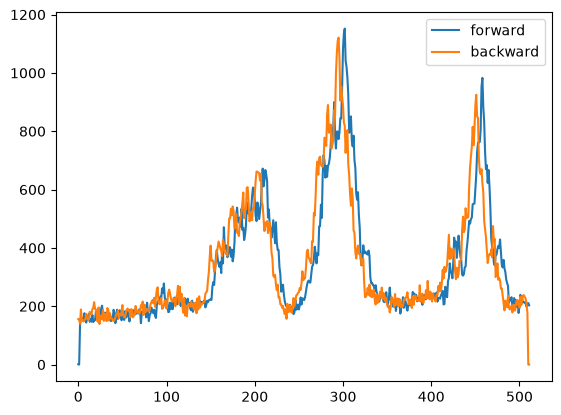

In [5]:
from tttrkit.ptuio.utils import estimate_bidirectional_prealign


chunks_to_skip = 3

ds = estimate_bidirectional_prealign(
    reader, 
    cfg,
    chunk_length=500_000,
    skip_chunks=chunks_to_skip,
    )

import matplotlib.pyplot as plt
_,ax = plt.subplots()

ax.plot(ds.forward.values,label = 'forward')
ax.plot(ds.backward.values,label='backward')
ax.legend()

plt.show()


## Fine-estimate bi-directional scan phase shift

Estimating bidirectional phase shift...
Skipped chunk 1/3
Skipped chunk 2/3
Skipped chunk 3/3
Shift -0.0032 → score 63698.61
Shift -0.0012 → score 67103.60
Shift 0.0008 → score 70515.85
Shift 0.0028 → score 76929.33
Shift 0.0048 → score 85745.61
Shift 0.0068 → score 96753.03
Shift 0.0088 → score 86539.95
Shift 0.0108 → score 77269.05
Shift 0.0128 → score 71235.09
Shift 0.0148 → score 67016.10
Shift 0.0168 → score 62656.30
Best estimated shift: 0.00690


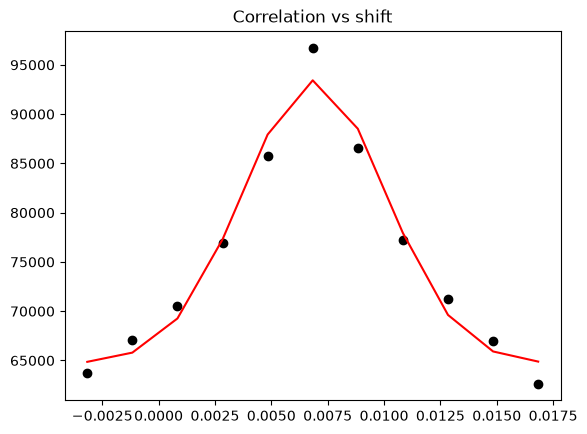

In [6]:
from tttrkit.ptuio.utils import estimate_bidirectional_shift

cfg.bidirectional_phase_shift = ds.phase_shift.values


estimated_phase = estimate_bidirectional_shift(
        reader=reader,
        config=cfg,
        chunk_length=500_000,
        skip_chunks=chunks_to_skip,
        )

optimized_phase_shift, scores = estimated_phase
_, ax = plt.subplots()
ax.plot(scores[0],scores[1],color='black',marker='o',linestyle='')
ax.plot(scores[0],scores[2],color='red',linestyle='-')
ax.set_title('Correlation vs shift')
plt.show()


## Reconstruct the image with the estimated shift

In [7]:
optimized_phase_shift

0.00689864133315258

In [8]:
cfg.bidirectional_phase_shift = optimized_phase_shift

reconstructor = ImageReconstructor(
        config=cfg, 
        laser_sync_rate=repetition_rate,
        tcspc_channels=tcspc_bins,
        tcspc_resolution=tcspc_resolution,
        outputs=['photon_count'],
        )

reader.reset()

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)



# chunk = reader.read(1_000_000)
# corrected_chunk = corrector.correct(chunk)
# reconstructor.update(corrected_chunk)

result = reconstructor.finalize()


image_corrected = result.photon_count.transpose(*order).values.astype(np.uint8)
stackview.slice(image_corrected, slice_number=0, colormap='gray', zoom_factor=1.0, zoom_spline_order=0, slider_text=slider_labels)

Reconstruction finished.
